<a href="https://colab.research.google.com/github/PreranaDey/pest-detect-app/blob/main/Crop_Recommendation_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
df = pd.read_csv("Crop_recommendation.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (2200, 8)


In [ ]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [ ]:
print("Column names:")

print(df.columns)

Column names:
Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')


In [ ]:
print("Missing values in each column:")

print(df.isnull().sum())

Missing values in each column:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


In [ ]:
print("Number of duplicate rows:")

print(df.duplicated().sum())

Number of duplicate rows:
0


In [ ]:
print("Number of different crops:")

print(df["label"].nunique())

print("\nCrop names:")

print(df["label"].unique())

Number of different crops:
22

Crop names:
['rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans'
 'mungbean' 'blackgram' 'lentil' 'pomegranate' 'banana' 'mango' 'grapes'
 'watermelon' 'muskmelon' 'apple' 'orange' 'papaya' 'coconut' 'cotton'
 'jute' 'coffee']


In [ ]:
print(
    df["label"].value_counts()
)

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


In [ ]:
X = df.drop("label", axis=1)

y = df["label"]

print("Input features:")
print(X.head())

print("\nTarget:")
print(y.head())

Input features:
    N   P   K  temperature   humidity        ph    rainfall
0  90  42  43    20.879744  82.002744  6.502985  202.935536
1  85  58  41    21.770462  80.319644  7.038096  226.655537
2  60  55  44    23.004459  82.320763  7.840207  263.964248
3  74  35  40    26.491096  80.158363  6.980401  242.864034
4  78  42  42    20.130175  81.604873  7.628473  262.717340

Target:
0    rice
1    rice
2    rice
3    rice
4    rice
Name: label, dtype: object


In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

print("Encoded values:")
print(y_encoded[:20])

print("\nCrop classes:")
print(encoder.classes_)

Encoded values:
[20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20]

Crop classes:
['apple' 'banana' 'blackgram' 'chickpea' 'coconut' 'coffee' 'cotton'
 'grapes' 'jute' 'kidneybeans' 'lentil' 'maize' 'mango' 'mothbeans'
 'mungbean' 'muskmelon' 'orange' 'papaya' 'pigeonpeas' 'pomegranate'
 'rice' 'watermelon']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1760, 7)
Testing data: (440, 7)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [ ]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
model = Sequential()

# First hidden layer
model.add(
    Dense(
        128,
        activation="relu",
        input_shape=(7,)
    )
)

# Dropout layer
model.add(
    Dropout(0.2)
)

# Second hidden layer
model.add(
    Dense(
        64,
        activation="relu"
    )
)

# Third hidden layer
model.add(
    Dense(
        32,
        activation="relu"
    )
)

# Output layer
model.add(
    Dense(
        22,
        activation="softmax"
    )
)

print("ANN model created!")

ANN model created!


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 22)             │           726 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,086 (47.21 KB)

 Trainable params: 12,086 (47.21 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

print("Early stopping configured!")

Early stopping configured!


In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.20,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2543 - loss: 2.8948 - val_accuracy: 0.4006 - val_loss: 2.5568
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4737 - loss: 2.0644 - val_accuracy: 0.6477 - val_loss: 1.4027
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7145 - loss: 1.0435 - val_accuracy: 0.8608 - val_loss: 0.6032
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8295 - loss: 0.5797 - val_accuracy: 0.8977 - val_loss: 0.3751
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8757 - loss: 0.4063 - val_accuracy: 0.9318 - val_loss: 0.2648
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9070 - loss: 0.3252 - val_accuracy: 0.9489 - val_loss: 0.2001
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9297 - loss: 0.2637 - val_accuracy: 0.9545 - val_loss: 0.1693
Epoch 8/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9240 - loss: 0.2295 - val_accuracy: 0.9631 - v

In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)

print(
    "Test Accuracy:",
    round(test_accuracy * 100, 2),
    "%"
)

Test Loss: 0.02967159077525139
Test Accuracy: 99.09 %


In [ ]:
y_probability = model.predict(X_test)

y_pred = np.argmax(
    y_probability,
    axis=1
)

print("Actual values:")
print(y_test[:10])

print("\nPredicted values:")
print(y_pred[:10])

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Actual values:
[16  1  6 11 16  3 20  2  1 16]

Predicted values:
[16  1  6 11 16  3 20  2  1 16]


In [ ]:
predicted_crops = encoder.inverse_transform(
    y_pred
)

actual_crops = encoder.inverse_transform(
    y_test
)

print("Actual crops:")
print(actual_crops[:10])

print("\nPredicted crops:")
print(predicted_crops[:10])

Actual crops:
['orange' 'banana' 'cotton' 'maize' 'orange' 'chickpea' 'rice' 'blackgram'
 'banana' 'orange']

Predicted crops:
['orange' 'banana' 'cotton' 'maize' 'orange' 'chickpea' 'rice' 'blackgram'
 'banana' 'orange']


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      0.95      0.95        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       1.00      0.95      0.97        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       0.95      1.00      0.98        20
      papaya       1.00    

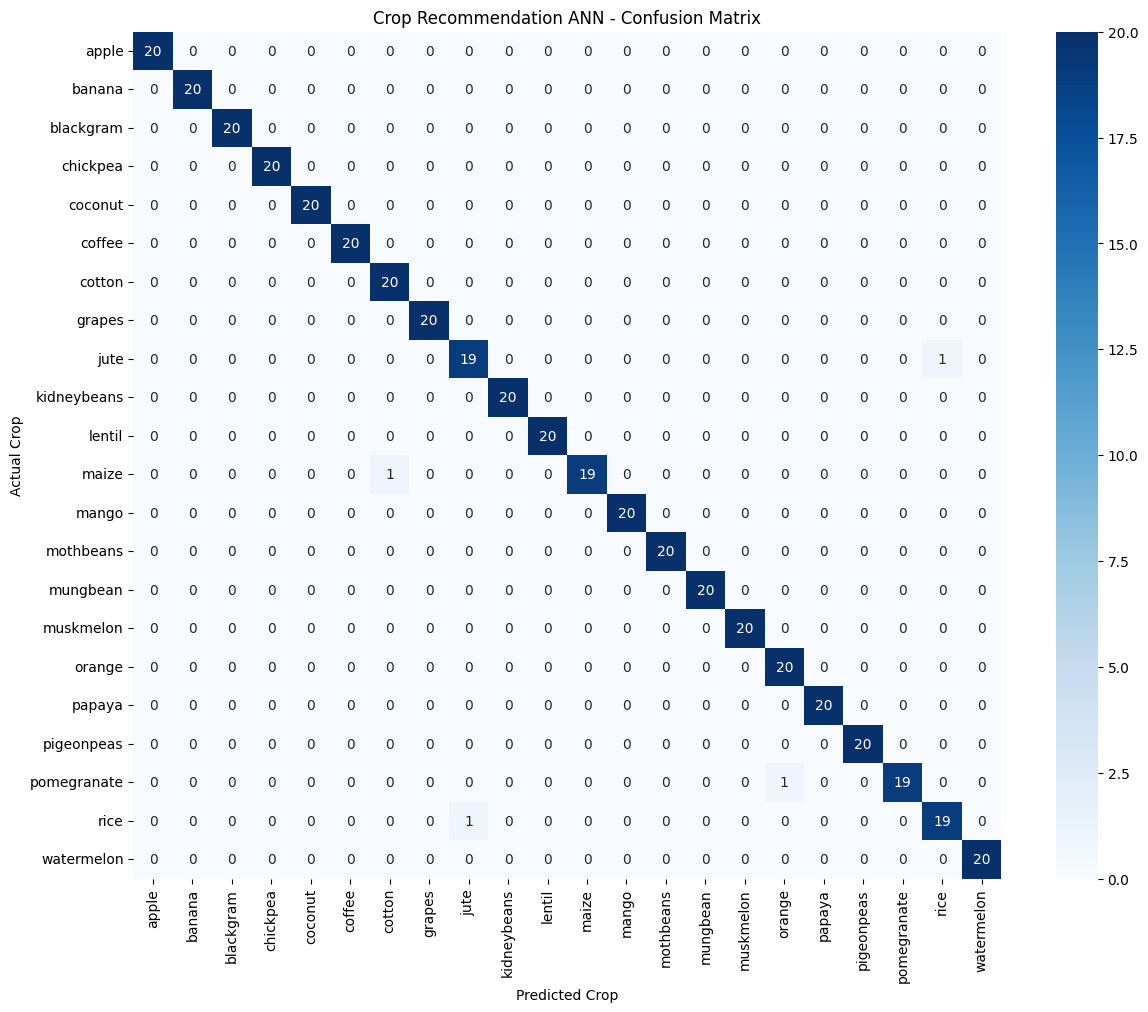

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(14, 11))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted Crop")
plt.ylabel("Actual Crop")
plt.title("Crop Recommendation ANN - Confusion Matrix")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()

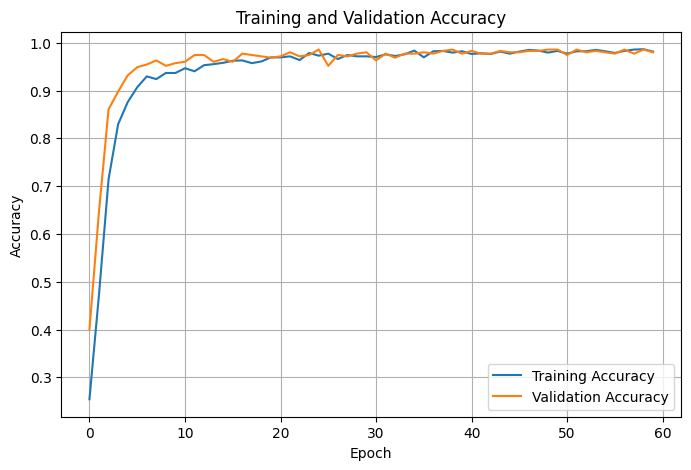

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid()

plt.show()

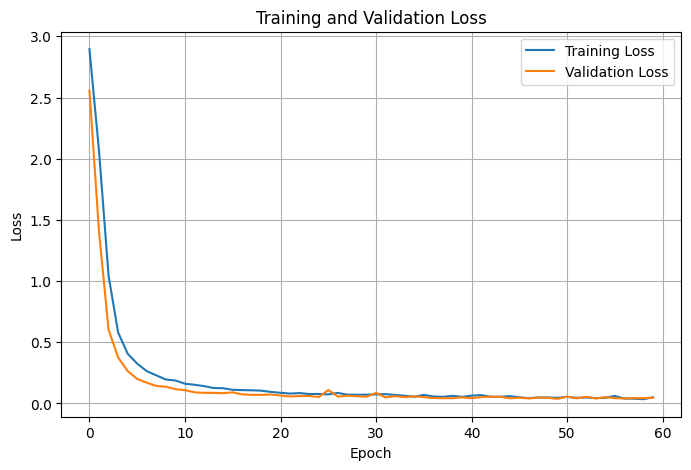

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid()

plt.show()

In [ ]:
def predict_crop():

    print("Enter Soil and Weather Information")
    print("-----------------------------------")

    N = float(input("Nitrogen (N): "))
    P = float(input("Phosphorus (P): "))
    K = float(input("Potassium (K): "))

    temperature = float(
        input("Temperature: ")
    )

    humidity = float(
        input("Humidity: ")
    )

    ph = float(
        input("Soil pH: ")
    )

    rainfall = float(
        input("Rainfall: ")
    )

    # Create input array
    new_data = np.array([[
        N,
        P,
        K,
        temperature,
        humidity,
        ph,
        rainfall
    ]])

    # Scale input
    new_data_scaled = scaler.transform(
        new_data
    )

    # Predict
    prediction = model.predict(
        new_data_scaled
    )

    # Get predicted class
    predicted_class = np.argmax(
        prediction,
        axis=1
    )[0]

    # Convert number to crop name
    crop = encoder.inverse_transform(
        [predicted_class]
    )[0]

    # Probability
    probability = np.max(
        prediction
    ) * 100

    print("\n==============================")
    print("CROP RECOMMENDATION")
    print("==============================")

    print(
        "Recommended Crop:",
        crop
    )

    print(
        "Confidence:",
        round(probability, 2),
        "%"
    )


predict_crop()

Enter Soil and Weather Information
-----------------------------------
Nitrogen (N): 90
Phosphorus (P): 42
Potassium (K): 43
Temperature: 20.8
Humidity: 82
Soil pH: 6.5
Rainfall: 202
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

CROP RECOMMENDATION
Recommended Crop: rice
Confidence: 93.74 %


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
